# Analysis of LSOA Population Demographics in England

This notebook presents a demographic analysis of the 2021 census data for England using the **'LSOA_data.csv'** dataset which contains population counts for 18 age groups across 33,755 Layer Super Output Areas (LSOAs) in England. This analysis intends to explore age profiles of the population at national and local levels, extract key insights from demographic indicators, compare distributions by area type, and classify areas based on their age structure.

In [ ]:
# Importing necessary libraries for data manipulation, numerical operations and data visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading CSV file into pandas DataFrame
df = pd.read_csv('LSOA_data.csv')
df

,LSOAName,LSOACode,PartOfCode,PartOfName,Total,Age4Under,Age5to9,Age10to14,Age15to19,Age20to24,...,Age40to44,Age45to49,Age50to54,Age55to59,Age60to64,Age65to69,Age70to74,Age75to79,Age80to84,Age85Over
0,City of London 001A,E01000001,E09000001,City of London,1473,52,34,32,23,90,...,114,105,89,73,83,119,102,57,57,35
1,City of London 001B,E01000002,E09000001,City of London,1384,33,24,22,31,100,...,92,98,122,88,87,76,69,59,43,30
2,City of London 001C,E01000003,E09000001,City of London,1613,39,32,33,23,96,...,111,113,155,118,111,86,85,50,31,33
3,City of London 001E,E01000005,E09000001,City of London,1101,52,45,35,89,118,...,61,58,87,82,67,35,26,17,14,12
4,Barking and Dagenham 016A,E01000006,E09000002,Barking and Dagenham,1842,153,127,110,122,124,...,164,153,121,85,70,66,41,18,17,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,Vale of White Horse 014H,E01035758,E07000180,Vale of White Horse,1169,39,45,58,38,63,...,67,76,81,57,49,57,70,46,70,77
33751,Vale of White Horse 015G,E01035759,E07000180,Vale of White Horse,1519,116,107,82,66,62,...,91,100,111,106,102,56,75,58,29,32
33752,Vale of White Horse 015H,E01035760,E07000180,Vale of White Horse,1610,206,152,97,49,59,...,156,62,41,30,24,14,15,13,20,33
33753,Vale of White Horse 015I,E01035761,E07000180,Vale of White Horse,1609,184,121,98,58,62,...,113,84,66,50,37,50,40,23,32,29


In [ ]:
# Overview of data types, column names and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LSOAName    33755 non-null  object
 1   LSOACode    33755 non-null  object
 2   PartOfCode  33755 non-null  object
 3   PartOfName  33755 non-null  object
 4   Total       33755 non-null  int64 
 5   Age4Under   33755 non-null  int64 
 6   Age5to9     33755 non-null  int64 
 7   Age10to14   33755 non-null  int64 
 8   Age15to19   33755 non-null  int64 
 9   Age20to24   33755 non-null  int64 
 10  Age25to29   33755 non-null  int64 
 11  Age30to34   33755 non-null  int64 
 12  Age35to39   33755 non-null  int64 
 13  Age40to44   33755 non-null  int64 
 14  Age45to49   33755 non-null  int64 
 15  Age50to54   33755 non-null  int64 
 16  Age55to59   33755 non-null  int64 
 17  Age60to64   33755 non-null  int64 
 18  Age65to69   33755 non-null  int64 
 19  Age70to74   33755 non-null  int64 
 20  Age75t

## Part 1: Bar Chart of the Age Profile

**1.1 Age profile of England**

In [ ]:
# Subset age group columns
age_groups = df[['Age4Under', 'Age5to9', 'Age10to14', 'Age15to19', 'Age20to24',
       'Age25to29', 'Age30to34', 'Age35to39', 'Age40to44', 'Age45to49',
       'Age50to54', 'Age55to59', 'Age60to64', 'Age65to69', 'Age70to74',
       'Age75to79', 'Age80to84', 'Age85Over']]

# Sum the counts for each age group across LSOAs
age_groups_count = age_groups.sum()

In [ ]:
# Calculate the total population of England
total_population = df['Total'].sum()

# Calculate the proportion that each age group represents in the total population
proportions = (age_groups_count / total_population) * 100
proportions



Age4Under    5.446709
Age5to9      5.927900
Age10to14    6.042414
Age15to19    5.698075
Age20to24    6.044152
Age25to29    6.577060
Age30to34    6.997093
Age35to39    6.718640
Age40to44    6.338266
Age45to49    6.377543
Age50to54    6.917748
Age55to59    6.737950
Age60to64    5.763944
Age65to69    4.898902
Age70to74    4.950725
Age75to79    3.608966
Age80to84    2.524659
Age85Over    2.429256
dtype: float64

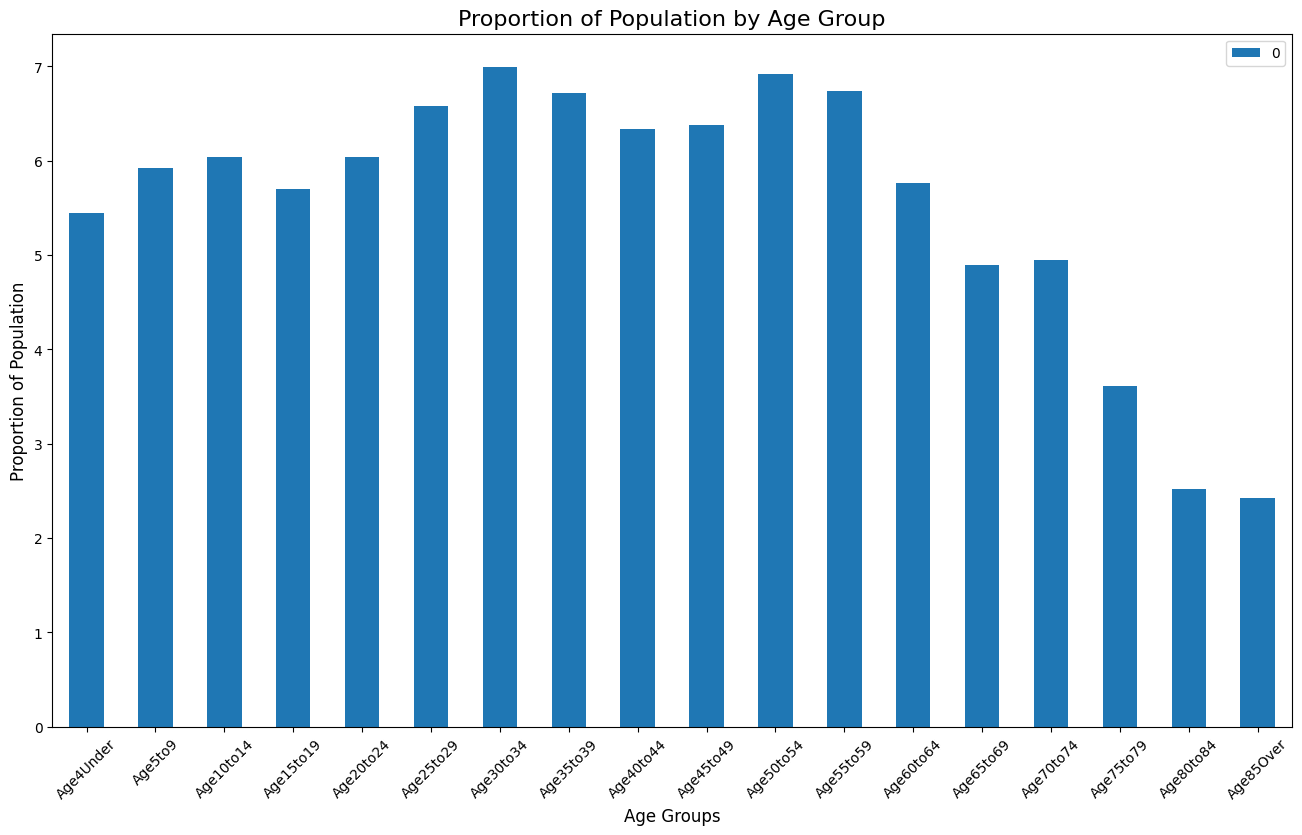

In [ ]:
# Plot the proportions of population by age group
proportions_df = pd.DataFrame(proportions)
proportions_df.plot(kind='bar', figsize=(16, 9))
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Proportion of Population', fontsize=12)
plt.title('Proportion of Population by Age Group', fontsize=16)
plt.xticks(rotation=45)
plt.show()

**1.2. Comparing LSOA Age Profiles with the National Average**

We will compare the distribution of the population by age range for the following LSOAs: E01005044 (Bury 026E), E01020395 (Dorset 024A) and E01009136 (Birmingham 014E) with the population distribution for the whole of England.

In [ ]:
# Filter the LSOAs of interest by their codes
lsoa_subset = df.loc[(df.LSOACode == 'E01005044') | (df.LSOACode == 'E01020395') | (df.LSOACode == 'E01009136')]
lsoa_name = lsoa_subset.LSOAName

# Extract age group data for these specific LSOAs
subset_age_count = lsoa_subset[['Age4Under', 'Age5to9', 'Age10to14', 'Age15to19', 'Age20to24',
       'Age25to29', 'Age30to34', 'Age35to39', 'Age40to44', 'Age45to49',
       'Age50to54', 'Age55to59', 'Age60to64', 'Age65to69', 'Age70to74',
       'Age75to79', 'Age80to84', 'Age85Over']]

# Calculate the proportions for each LSOA by dividing by its own total population
age_proportions = (subset_age_count.div(lsoa_subset['Total'], axis=0)) * 100

# Set the LSOAName as the index for clear labeling in the plot legend
age_proportions = pd.DataFrame(age_proportions.set_index(lsoa_name))
age_proportions



,Age4Under,Age5to9,Age10to14,Age15to19,Age20to24,Age25to29,Age30to34,Age35to39,Age40to44,Age45to49,Age50to54,Age55to59,Age60to64,Age65to69,Age70to74,Age75to79,Age80to84,Age85Over
LSOAName,,,,,,,,,,,,,,,,,,
Bury 026E,10.963794,13.921469,14.941356,9.841917,4.232534,4.895461,6.221316,6.731260,5.966344,5.201428,3.926568,2.753697,3.059663,2.906680,1.835798,1.325854,0.866905,0.407955
Birmingham 014E,6.026151,5.798749,5.173394,6.310404,5.059693,5.798749,7.220011,8.470722,4.661740,5.059693,5.571347,5.798749,6.367254,6.083002,5.457646,4.718590,3.240478,3.183627
Dorset 024A,1.154250,2.203568,2.570829,3.147954,3.882476,2.885624,1.941238,1.941238,3.200420,3.934942,4.459601,6.190976,7.869885,8.656873,11.332634,10.965373,10.178384,13.483736


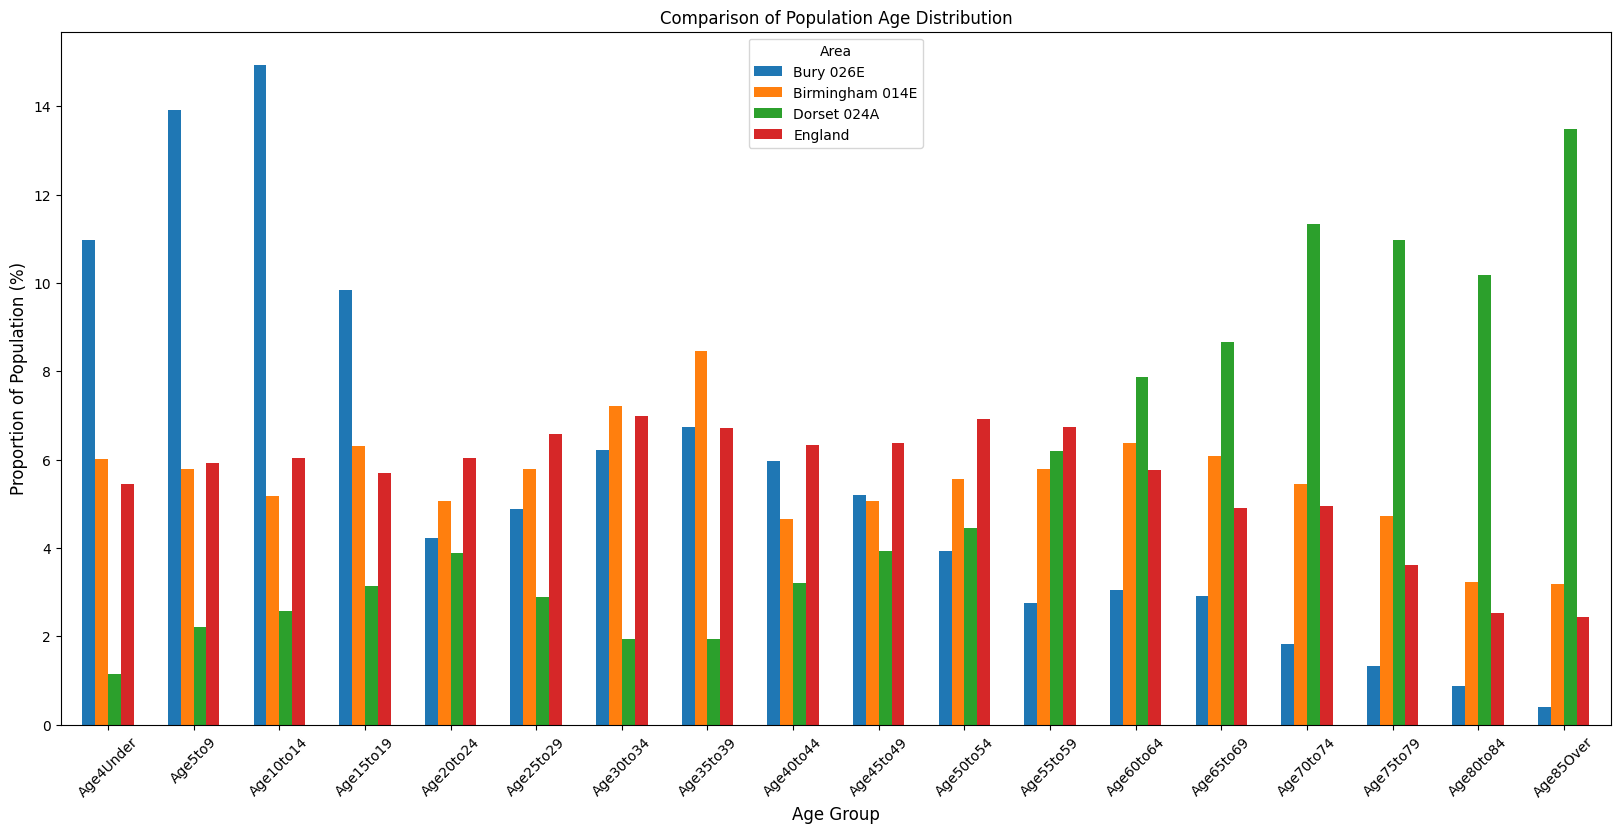

In [ ]:
# Transpose the DataFrame and add national average for comparison
age_proportions_transposed = age_proportions.T
age_proportions_transposed['England'] = proportions

# Plot comparison bar chart
age_proportions_transposed.plot(kind='bar', figsize=(20, 9), width=0.6)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Proportion of Population (%)', fontsize=12)
plt.title('Comparison of Population Age Distribution', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Area')
plt.show()

**1.3. Comments on the Age Profile Differences:**

- **Bury 026E:** This area shows proportions from age under 4 to age 19 far above the other areas and the England average. The remaining age groups are similar or below the national average. These peaks within the children and teenager residents suggest that the area may be suburban or predominantly family-oriented communities.

- **Dorset 024A:** On the contrary, this area contains a much higher proportion of residents over the age of 60 than the other areas and the national average. This suggests that it is a popular retirement area, perhaps along the coast and with significant nature zones.

- **Birmingham 014E:** This LSOA displays a population distribution much closer to the England average, with slightly higher adult residents than the national average from age 30 to 39, and from residents over 60. The more consistent distribution of residents with a clear peak in working adults between 30 to 39 suggests this is a location with significant working opportunities.

## Part 2: Distribution of the Younger, Older and Median Ages in Each LSOA

**2.1. Adding New Demographic Variables**

We will create three new features for each LSOA: the proportion of "younger" residents, the proportion of "older" residents, and an estimate of the median age. The younger residents are those in the first four age groups (Age4Under, Age5to9, Age10to14, Age15to19). Older residents are the ones in the last five age groups, starting with Age65to69.

In [ ]:
# Proportion of younger and older residents
younger_residents = df[['Age4Under', 'Age5to9', 'Age10to14', 'Age15to19']].sum(axis=1)
older_residents = df[['Age65to69', 'Age70to74',
       'Age75to79', 'Age80to84', 'Age85Over']].sum(axis=1)
younger_residents_pct = (younger_residents / df['Total']) * 100
older_residents_pct = (older_residents / df['Total']) * 100

# Copy the original DataFrame to modify it
df_copy = df.copy()
df_copy.reset_index(inplace=True)

# Add the new columns to the DataFrame copy
df_copy['YoungerProportion'] = younger_residents_pct
df_copy['OlderProportion'] = older_residents_pct
df_copy = df_copy.drop(columns='index')
df_copy

,LSOAName,LSOACode,PartOfCode,PartOfName,Total,Age4Under,Age5to9,Age10to14,Age15to19,Age20to24,...,Age50to54,Age55to59,Age60to64,Age65to69,Age70to74,Age75to79,Age80to84,Age85Over,YoungerProportion,OlderProportion
0,City of London 001A,E01000001,E09000001,City of London,1473,52,34,32,23,90,...,89,73,83,119,102,57,57,35,9.572301,25.118805
1,City of London 001B,E01000002,E09000001,City of London,1384,33,24,22,31,100,...,122,88,87,76,69,59,43,30,7.947977,20.014451
2,City of London 001C,E01000003,E09000001,City of London,1613,39,32,33,23,96,...,155,118,111,86,85,50,31,33,7.873528,17.668940
3,City of London 001E,E01000005,E09000001,City of London,1101,52,45,35,89,118,...,87,82,67,35,26,17,14,12,20.072661,9.445958
4,Barking and Dagenham 016A,E01000006,E09000002,Barking and Dagenham,1842,153,127,110,122,124,...,121,85,70,66,41,18,17,16,27.795874,8.577633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,Vale of White Horse 014H,E01035758,E07000180,Vale of White Horse,1169,39,45,58,38,63,...,81,57,49,57,70,46,70,77,15.397776,27.373824
33751,Vale of White Horse 015G,E01035759,E07000180,Vale of White Horse,1519,116,107,82,66,62,...,111,106,102,56,75,58,29,32,24.423963,16.458196
33752,Vale of White Horse 015H,E01035760,E07000180,Vale of White Horse,1610,206,152,97,49,59,...,41,30,24,14,15,13,20,33,31.304348,5.900621
33753,Vale of White Horse 015I,E01035761,E07000180,Vale of White Horse,1609,184,121,98,58,62,...,66,50,37,50,40,23,32,29,28.651336,10.814170


**2.2. Estimating the Median Age**

In [ ]:
# Create a mapping from age group names to the lower boundary of their age range
age_column_names = df.columns[5:]
lower_ages = np.arange(0, 86, 5)
age_map = pd.Series(data=lower_ages, index=age_column_names)

def findMedian(counts):
    """
    Estimates the median age from a pandas Series of age group counts using interpolation.
    """
    # Calculate cumulative fraction of the group
    cumul_fract = counts.cumsum() / sum(counts)

    # Find the median age group, that is the first bin where cumulative fraction is >= 0.5
    cumul_age_groups = cumul_fract[cumul_fract >= 0.5]
    median_name = cumul_age_groups.index[0]
    median_position = cumul_fract.index.get_loc(median_name)

    # Get the cumulative fraction of the bin before the median group
    prev_fract = cumul_fract.iloc[median_position - 1]

    # Fraction of the population within the median bin and how much it needs to reach 50%
    fract_in_bin = cumul_fract[median_name] - prev_fract
    fract_to_reach_median = 0.5 - prev_fract

    # Interpolation
    median_age = age_map[median_name] + 5 * (fract_to_reach_median / fract_in_bin)
    return median_age

findMedian(age_groups_count)




np.float64(40.4322611250074)

In [ ]:
# Apply function across age group columns
df_copy2 = df_copy.assign(MedianAge = age_groups.apply(findMedian, axis=1))
df_copy2

,LSOAName,LSOACode,PartOfCode,PartOfName,Total,Age4Under,Age5to9,Age10to14,Age15to19,Age20to24,...,Age55to59,Age60to64,Age65to69,Age70to74,Age75to79,Age80to84,Age85Over,YoungerProportion,OlderProportion,MedianAge
0,City of London 001A,E01000001,E09000001,City of London,1473,52,34,32,23,90,...,73,83,119,102,57,57,35,9.572301,25.118805,44.276316
1,City of London 001B,E01000002,E09000001,City of London,1384,33,24,22,31,100,...,88,87,76,69,59,43,30,7.947977,20.014451,43.913043
2,City of London 001C,E01000003,E09000001,City of London,1613,39,32,33,23,96,...,118,111,86,85,50,31,33,7.873528,17.668940,43.896396
3,City of London 001E,E01000005,E09000001,City of London,1101,52,45,35,89,118,...,82,67,35,26,17,14,12,20.072661,9.445958,34.851695
4,Barking and Dagenham 016A,E01000006,E09000002,Barking and Dagenham,1842,153,127,110,122,124,...,85,70,66,41,18,17,16,27.795874,8.577633,34.454023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,Vale of White Horse 014H,E01035758,E07000180,Vale of White Horse,1169,39,45,58,38,63,...,57,49,57,70,46,70,77,15.397776,27.373824,44.888060
33751,Vale of White Horse 015G,E01035759,E07000180,Vale of White Horse,1519,116,107,82,66,62,...,106,102,56,75,58,29,32,24.423963,16.458196,40.027473
33752,Vale of White Horse 015H,E01035760,E07000180,Vale of White Horse,1610,206,152,97,49,59,...,30,24,14,15,13,20,33,31.304348,5.900621,31.716102
33753,Vale of White Horse 015I,E01035761,E07000180,Vale of White Horse,1609,184,121,98,58,62,...,50,37,50,40,23,32,29,28.651336,10.814170,32.968750


**2.3. Summary Statistics and Distributions**

In [ ]:
df_summary = df_copy2[['Total', 'YoungerProportion', 'OlderProportion', 'MedianAge']]
df_summary.describe()

,Total,YoungerProportion,OlderProportion,MedianAge
count,33755.000000,33755.000000,33755.000000,33755.000000
mean,1673.532543,22.783191,18.916786,42.032147
std,353.289631,5.530069,8.551985,7.782742
min,999.000000,1.808067,0.073611,14.530516
25%,1443.000000,19.229739,12.399500,36.128752
50%,1608.000000,22.318339,18.275058,41.460674
75%,1835.000000,25.868932,24.685133,47.821934
max,9900.000000,62.879349,65.540927,71.875000


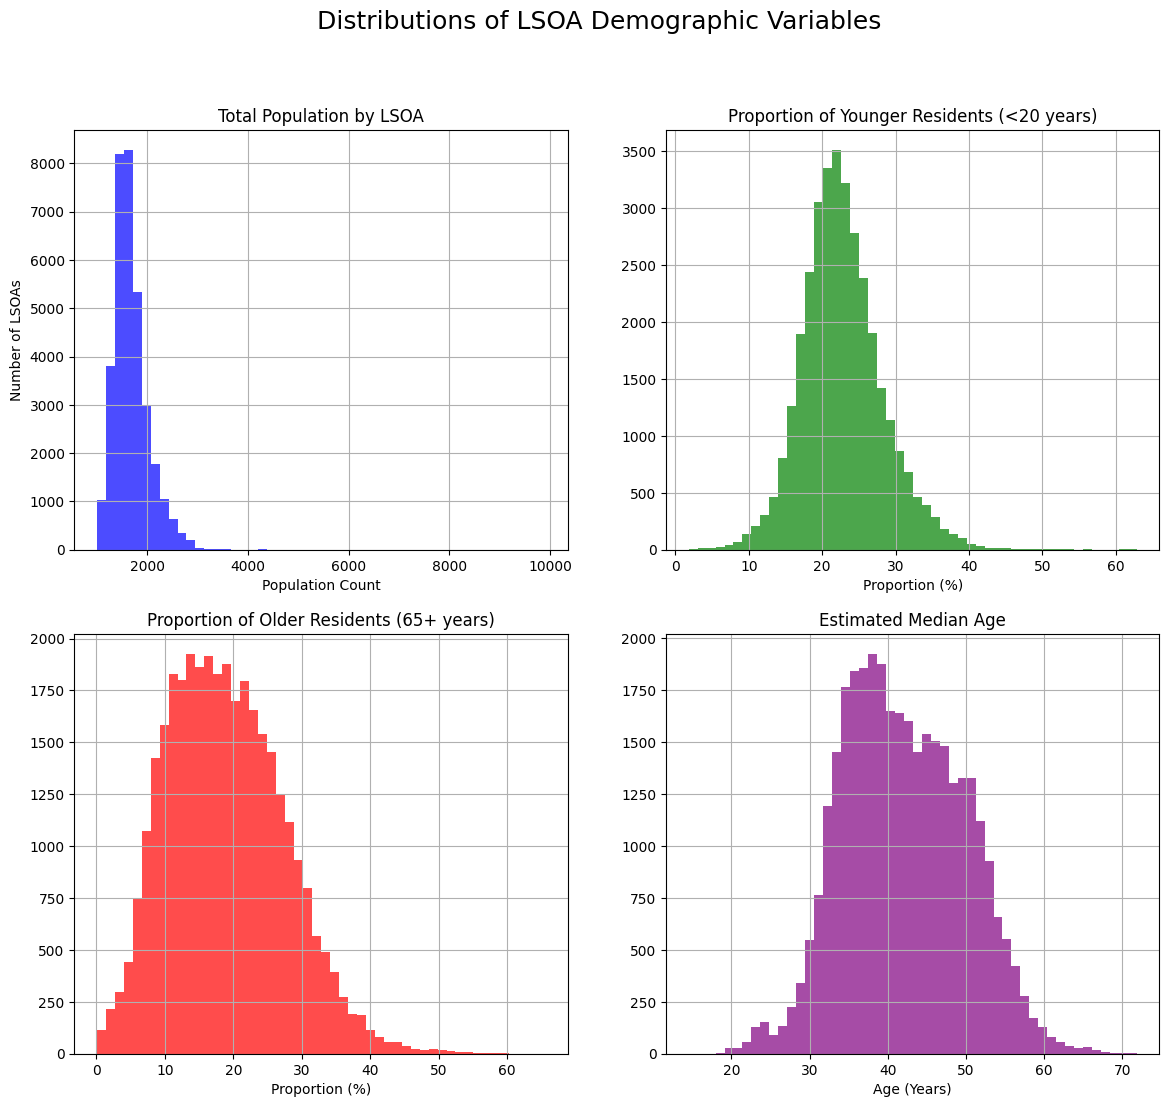

In [ ]:
# Create histograms for each variable to visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Distributions of LSOA Demographic Variables', fontsize=18)

df_summary['Total'].hist(bins=50, ax=axes[0, 0], color='blue', alpha=0.7)
axes[0, 0].set_title('Total Population by LSOA')
axes[0, 0].set_xlabel('Population Count')
axes[0, 0].set_ylabel('Number of LSOAs')

df_summary['YoungerProportion'].hist(bins=50, ax=axes[0, 1], color='green', alpha=0.7)
axes[0, 1].set_title('Proportion of Younger Residents (<20 years)')
axes[0, 1].set_xlabel('Proportion (%)')

df_summary['OlderProportion'].hist(bins=50, ax=axes[1, 0], color='red', alpha=0.7)
axes[1, 0].set_title('Proportion of Older Residents (65+ years)')
axes[1, 0].set_xlabel('Proportion (%)')

df_summary['MedianAge'].hist(bins=50, ax=axes[1, 1], color='purple', alpha=0.7)
axes[1, 1].set_title('Estimated Median Age')
axes[1, 1].set_xlabel('Age (Years)')
plt.show()


**Comments on the Distributions:**

- **Total Population:** The histogram for the total population shows a distribution clustered together and piled up on one side around the lower values. Which comes to show that most areas have under 2000 residents.

- **Younger Proportion:** The YoungerProportion histogram shows a symmetric distribution that clusters in the center and tapers off on either side. Most areas have a percentage of younger population within the 20-25%.

- **Older Proportion:** In the OlderProportion histogram, the distribution follows a similar shape, perhaps slightly skewed to one side. Most areas have 10-20% of older population.

- **Median Age:** The MedianAge histogram has a similar distribution of tails. As in the previous histograms, the shape piles up in middle which shows that a lot of the areas have their median age between 35 and 50.

**2.4. Comparing National Median Age with the Median of LSOA Medians**

In [ ]:
# Median age for England
england_median = findMedian(age_groups_count)

# 50th percentile value for LSOA median ages
lsoa_median_of_medians = df_copy2['MedianAge'].median()
print(f'Median Age for England: {england_median:.2f} years')
print(f'Median of LSOA Median Ages: {lsoa_median_of_medians:.2f}')


Median Age for England: 40.43 years
Median of LSOA Median Ages: 41.46


**Comments on the Differences:**

The two values differ a little because the median for the whole of England takes all the population ages and finds the median. This calculation is based on the entire population. On the other side, the 50th percentile of the median ages by LSOA takes the median age for each LSOA and finds the middle value. It is calculated based on a list of medians. They don't have the same population parameters.

## Part 3: Comparing the Median Age Distributions by Area Type

We will compare distributions grouping the LSO areas by type.

**3.1. Area Type Classification**

In [ ]:
# Extract first 3 characters from 'PartOfCode' column
df_part_of_code = df_copy2['PartOfCode'].str[:3]

# Dictionary mapping area type codes to descriptive names
area_types = {
    'E06': 'Unitary Authorities',
    'E07': 'Non-metropolitan Districts',
    'E08': 'Metropolitan Districts',
    'E09': 'London Borough'
}

# Map characters from 'PartOfCode' to descriptive names
df_part_of_code = df_part_of_code.map(area_types)

# Add 'AreaType' column to the DataFrame
df_copy2['AreaType'] = df_part_of_code
df_copy2

,LSOAName,LSOACode,PartOfCode,PartOfName,Total,Age4Under,Age5to9,Age10to14,Age15to19,Age20to24,...,Age60to64,Age65to69,Age70to74,Age75to79,Age80to84,Age85Over,YoungerProportion,OlderProportion,MedianAge,AreaType
0,City of London 001A,E01000001,E09000001,City of London,1473,52,34,32,23,90,...,83,119,102,57,57,35,9.572301,25.118805,44.276316,London Borough
1,City of London 001B,E01000002,E09000001,City of London,1384,33,24,22,31,100,...,87,76,69,59,43,30,7.947977,20.014451,43.913043,London Borough
2,City of London 001C,E01000003,E09000001,City of London,1613,39,32,33,23,96,...,111,86,85,50,31,33,7.873528,17.668940,43.896396,London Borough
3,City of London 001E,E01000005,E09000001,City of London,1101,52,45,35,89,118,...,67,35,26,17,14,12,20.072661,9.445958,34.851695,London Borough
4,Barking and Dagenham 016A,E01000006,E09000002,Barking and Dagenham,1842,153,127,110,122,124,...,70,66,41,18,17,16,27.795874,8.577633,34.454023,London Borough
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,Vale of White Horse 014H,E01035758,E07000180,Vale of White Horse,1169,39,45,58,38,63,...,49,57,70,46,70,77,15.397776,27.373824,44.888060,Non-metropolitan Districts
33751,Vale of White Horse 015G,E01035759,E07000180,Vale of White Horse,1519,116,107,82,66,62,...,102,56,75,58,29,32,24.423963,16.458196,40.027473,Non-metropolitan Districts
33752,Vale of White Horse 015H,E01035760,E07000180,Vale of White Horse,1610,206,152,97,49,59,...,24,14,15,13,20,33,31.304348,5.900621,31.716102,Non-metropolitan Districts
33753,Vale of White Horse 015I,E01035761,E07000180,Vale of White Horse,1609,184,121,98,58,62,...,37,50,40,23,32,29,28.651336,10.814170,32.968750,Non-metropolitan Districts


**3.2. Visualizing Median Age Distributions by Area Type**

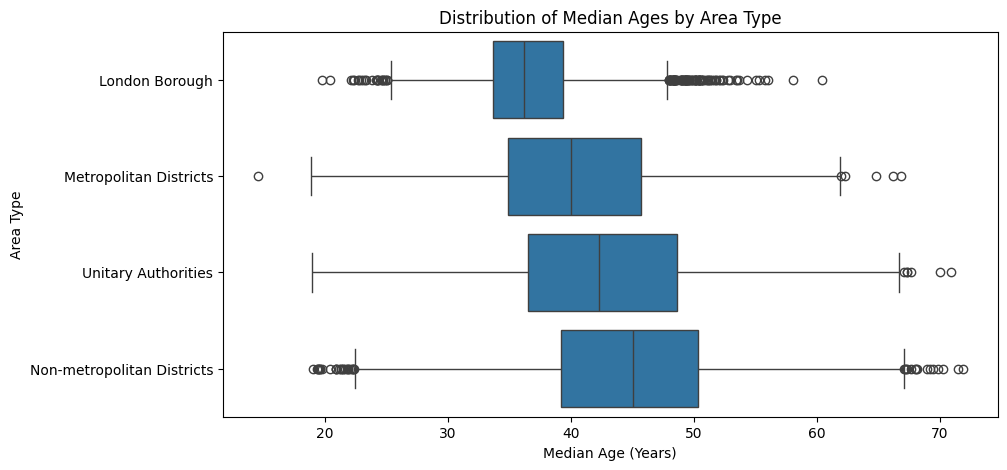

In [ ]:
# Create box plot to compare and visualize distributions
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_copy2, x='MedianAge', y='AreaType')
plt.xlabel('Median Age (Years)')
plt.ylabel('Area Type')
plt.title('Distribution of Median Ages by Area Type')
plt.show()

**3.3. Comments on the Differences by Area Type**

- **London Borough:** The lowest median age is found in the London Boroughs which suggests that it is comprised of a younger population that primarily includes students and working age population.

- **Metropolitan Districts:** These large urban areas outside of London also have a relatively young population, with a median age slightly higher than London but still below the other two area types.

- **Non-metropolitan Districts:** Non-metropolitan areas have the highest median age. These are typically more rural areas and have a wider spread than metropolitan districts, which strongly suggests that they are populated by residents in the retirement age.

- **Unitary Authorities:** Unitary Authorities also have a wide spread, these areas tend to be made up of urban, densely-populated locations with a diverse range of age groups, some young, some quite old, and many in between. In contrast, London Boroughs show a tight spread of consistently young population across its distribution.

## Part 4: Classification of Unusual Areas by Proportions

**4.1. Relationship between Younger and Older Proportions**

To explore the relationship between the proportions of young and old residents, we will create a scatter plot. Each point on the plot will represent one LSOA.

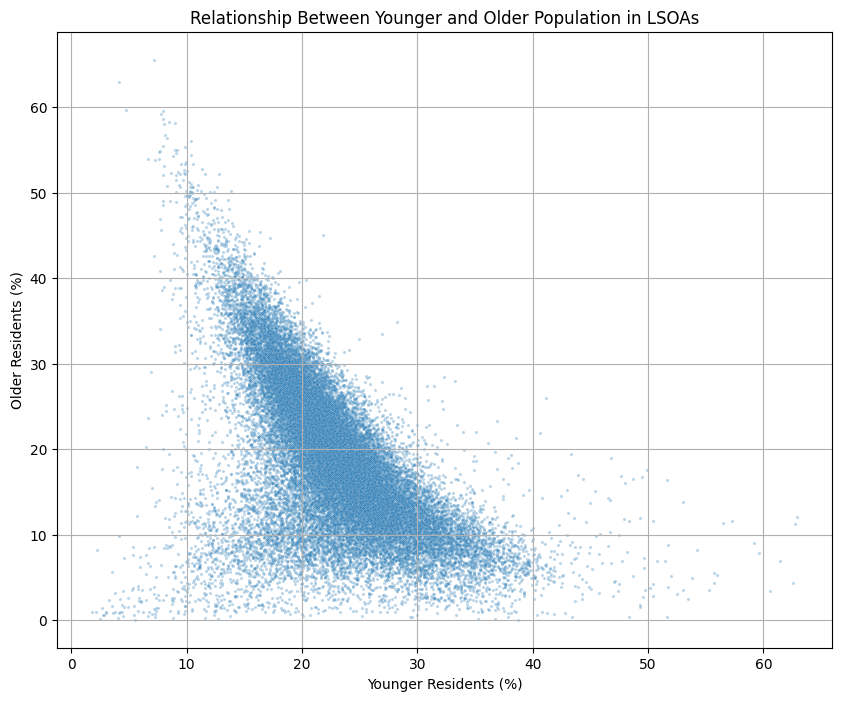

In [ ]:
# Extract columns of interest
df_copy2_subset = df_copy2[['YoungerProportion', 'OlderProportion', 'AreaType']]

# Create scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_copy2_subset, x='YoungerProportion', y='OlderProportion', s=5, alpha=0.3)
plt.title('Relationship Between Younger and Older Population in LSOAs')
plt.xlabel('Younger Residents (%)')
plt.ylabel('Older Residents (%)')
plt.grid(True)
plt.show()

**4.2. Comments on the Shape of the Scatter Plot:**

The overall shape points to a negative relationship between the younger and older population. Although the main cluster of points gather around the 15-30% for both age groups, the tendency is that the higher the older population, the lower the younger population, and vice versa. The three extreme corners represent different demographic profiles: the bottom-left corner shows a low proportion of both younger (under 4 to 19) and older population (over 65), which means it is probably a working area such as Greater London; the top-left corner shows a high proportion of mostly older residents and a low proportion of young residents, these areas must be retirement areas; and the bottom-right corner shows a high proportion of young residents but a low proportion of older residents, these areas are probably family-oriented and residential communities with lots of children, perhaps also popular locations for university students.



**4.3. Classification of Extreme Areas**

Based on the analysis of the scatter plot, we can define a set of rules to classify each LSOA.

- **Classification Rules:**

    - Bottom-left: "Workers"
    - Top-left: "Retirees"
    - Bottom-right: "Young Families/Students"

- An LSOA is in the "Workers" category if YoungerProportion is less than 15% and OlderProportion is less than 20%.

- An LSOA is in the "Retirees" category if YoungerProportion is less than 15% and OlderProportion is higher than 40%.

- An LSOA is in the "Young Families/Students" category if YoungerProportion is higher than 35% and OlderProportion is less than 20%.

In [ ]:
# Define function to apply classification rules
def classify_lsoa(row):
    younger = row['YoungerProportion']
    older = row['OlderProportion']
    if younger < 15 and older < 20:
        return 'Workers'
    elif younger < 15 and older > 40:
        return 'Retirees'
    elif younger > 35 and older < 20:
        return 'Young Families/Students'
    else:
        return 'Normal'

# Apply function to create classification column
df_copy2_subset = df_copy2_subset.assign(Classification = df_copy2_subset.apply(classify_lsoa, axis=1))
df_copy2_subset

,YoungerProportion,OlderProportion,AreaType,Classification
0,9.572301,25.118805,London Borough,Normal
1,7.947977,20.014451,London Borough,Normal
2,7.873528,17.668940,London Borough,Workers
3,20.072661,9.445958,London Borough,Normal
4,27.795874,8.577633,London Borough,Normal
...,...,...,...,...
33750,15.397776,27.373824,Non-metropolitan Districts,Normal
33751,24.423963,16.458196,Non-metropolitan Districts,Normal
33752,31.304348,5.900621,Non-metropolitan Districts,Normal
33753,28.651336,10.814170,Non-metropolitan Districts,Normal


**4.4. Pivot Table and Bar Chart of Classifications by Area Type**

We will use a pivot table to count the number of LSOAs in each classification for each area type. This will reveal if certain extreme profiles are more common in particular types of areas. We will then visualize the counts for the extreme types.

In [ ]:
# Create pivot table
df_copy2_pivot_table = df_copy2_subset.pivot_table(index='AreaType', columns=['Classification'], aggfunc='size')
df_copy2_pivot_table

Classification,Normal,Retirees,Workers,Young Families/Students
AreaType,,,,
London Borough,4622,1,288,83
Metropolitan Districts,6725,25,158,427
Non-metropolitan Districts,12155,233,103,108
Unitary Authorities,8323,121,172,211


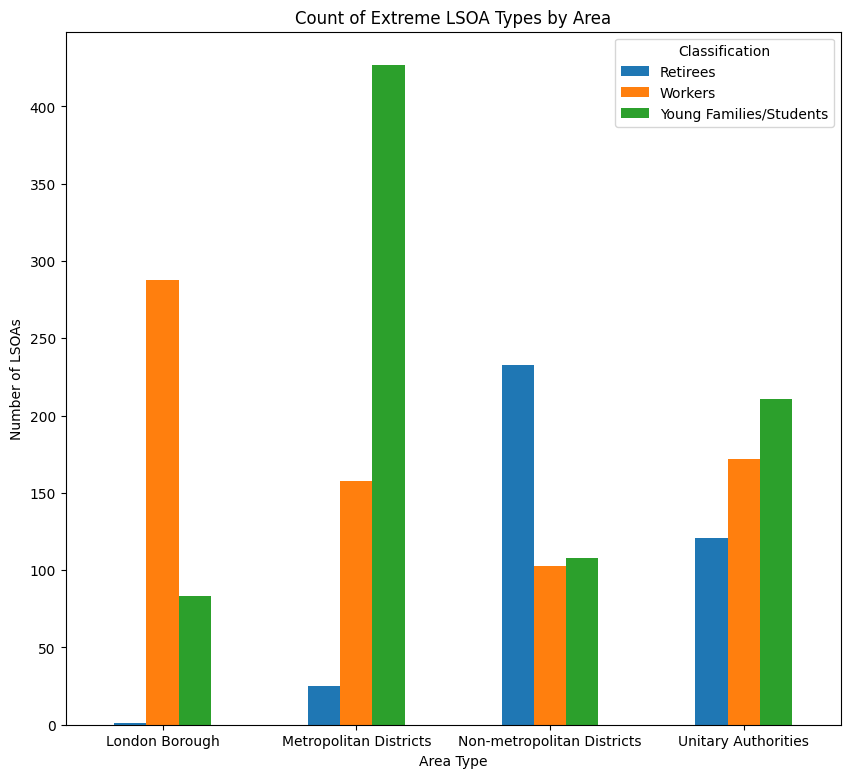

In [ ]:
# Exclude 'Normal' category for the bar chart
df_copy2_extremes = df_copy2_pivot_table[['Retirees', 'Workers', 'Young Families/Students']]

# Plot the bar chart
df_copy2_extremes.plot(kind='bar', figsize=(10, 9))
plt.xlabel('Area Type')
plt.ylabel('Number of LSOAs')
plt.title('Count of Extreme LSOA Types by Area')
plt.xticks(rotation=0)
plt.show()

**Comments on the Bar Chart:**

- **Workers:** Workers are predominantly represented in the London Boroughs as more job opportunities can be found there.

- **Retirees:** The bar chart shows that 'Retirees' areas are more common in Non-metropolitan districts followed by Unitary Authorities which matches the higher median age and wider spread that what was represented in the previous boxplot for that age category.

- **Young Families/Students:** These are most common in urban areas outside of London like Metropolitan Districts. These areas often host universities that attract a large quantity of students and may have suburban areas thar are appealing to families, leading to a higher proportion of younger residents.

- **Unitary Authorities:** These areas show more equal gaps between classes reflecting a more balanced spread of population groups.